In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpld3 as mpl

#Importar modelos do módulo de aprendizado do scikit:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)
from sklearn.cross_validation import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import metrics

ModuleNotFoundError: No module named 'mpld3'

In [ ]:
#Inserção de dados para o dataframe

In [ ]:
breastcancer = pd.read_csv('https://drive.google.com/file/d/1wgqIieWZO91U-fhSPcaLmAli8CGRsTNR/view?usp=drive_link',header = 0)


NameError: name 'pd' is not defined

In [ ]:
breastcancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
#Limpeza e preparação dos dados

In [ ]:
breastcancer.drop('id',axis=1,inplace=True)
breastcancer.drop('Unnamed: 32',axis=1,inplace=True)
# size of the dataframe
len(breastcancer)

569

In [ ]:
breastcancer.diagnosis.unique()

array(['M', 'B'], dtype=object)

In [ ]:
breastcancer['diagnosis'] = breastcancer['diagnosis'].map({'M':1,'B':0})
breastcancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
#checando dados nulos

In [ ]:
breastcancer.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [ ]:
#Matriz de Correlação
#Esta expressão retornará uma matriz de correlação das colunas selecionadas, onde os valores da diagonal principal representam a correlação de cada coluna consigo mesma, e os demais valores representam a correlação entre as colunas. Os valores variam de -1 a 1, onde -1 indica uma correlação negativa perfeita, 0 indica nenhuma correlação e 1 indica uma correlação positiva perfeita

In [ ]:
breastcancer[['radius_mean','perimeter_mean','area_mean','compactness_mean','concave points_mean']].corr().style.background_gradient(cmap='Blues', low=-0.1, high=0.1, vmin=-1, vmax=+1)

,radius_mean,perimeter_mean,area_mean,compactness_mean,concave points_mean
radius_mean,1.000000,0.997855,0.987357,0.506124,0.822529
perimeter_mean,0.997855,1.000000,0.986507,0.556936,0.850977
area_mean,0.987357,0.986507,1.000000,0.498502,0.823269
compactness_mean,0.506124,0.556936,0.498502,1.000000,0.831135
concave points_mean,0.822529,0.850977,0.823269,0.831135,1.000000


In [ ]:
#Explorando os dados

In [ ]:

breastcancer.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


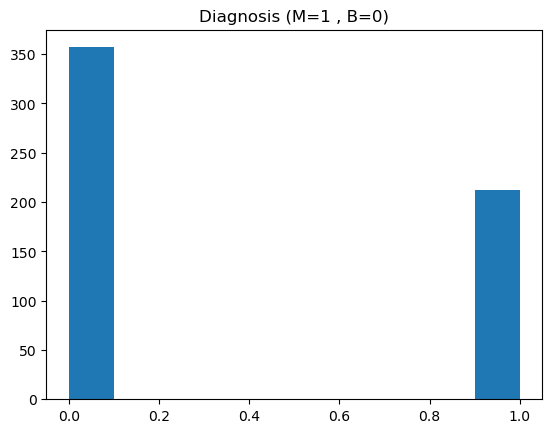

In [ ]:
breastcancer.describe()
plt.hist(breastcancer['diagnosis'])
plt.title('Diagnosis (M=1 , B=0)')
plt.show()

In [ ]:
#Características do núcleo vs diagnóstico

In [ ]:
features_mean=list(breastcancer.columns[1:11])
# dividir dataframe em dois com base no diagnóstico
dfM=breastcancer[breastcancer['diagnosis'] ==1]
dfB=breastcancer[breastcancer['diagnosis'] ==0]


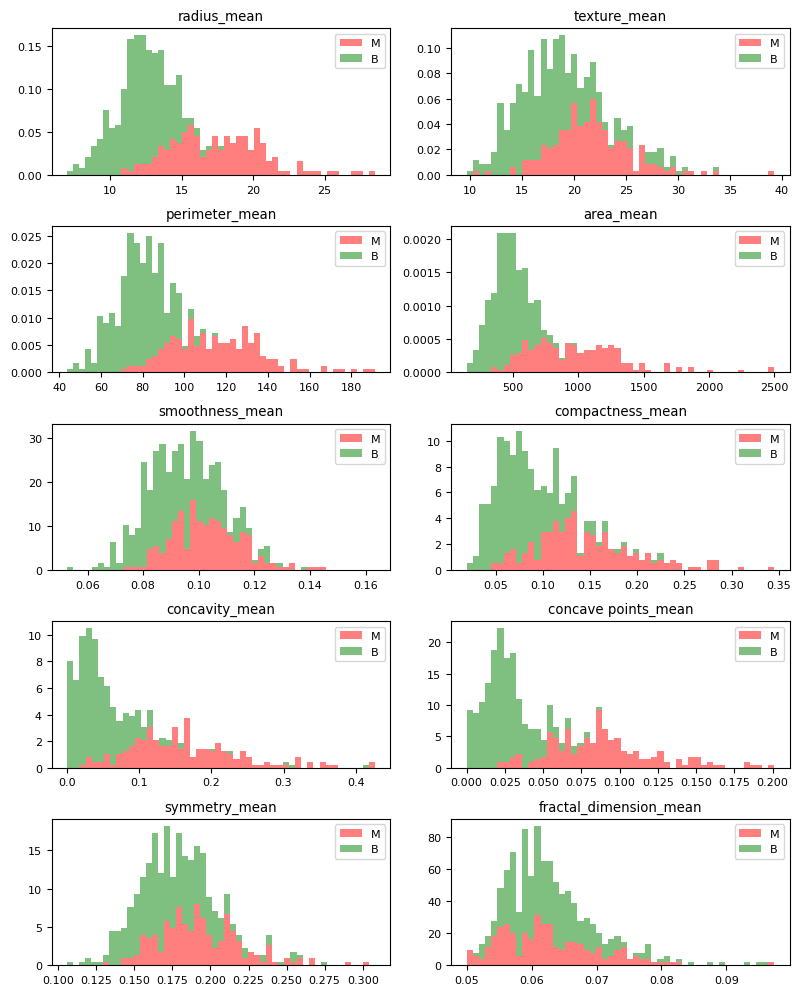

In [ ]:
#criando um histograma empilhado
plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8,10))
axes = axes.ravel()
for idx,ax in enumerate(axes):
    ax.figure
    binwidth= (max(breastcancer[features_mean[idx]]) - min(breastcancer[features_mean[idx]]))/50
    ax.hist([dfM[features_mean[idx]],dfB[features_mean[idx]]], bins=np.arange(min(breastcancer[features_mean[idx]]), max(breastcancer[features_mean[idx]]) + binwidth, binwidth) , alpha=0.5,stacked=True, density = True, label=['M','B'],color=['r','g'])
    ax.legend(loc='upper right')
    ax.set_title(features_mean[idx])
plt.tight_layout()
plt.show()

In [ ]:
#Criando um conjunto de teste e um conjunto de treinamento

In [ ]:
from sklearn.model_selection import train_test_split
trainbreastcancer, testbreastcancer = train_test_split(breastcancer, test_size = 0.3)

In [ ]:
#Função genérica para fazer um modelo de classificação e acessar o desempenho
def classification_model(model, data, predictors, outcome):
  #ajustando o modelo
  model.fit(data[predictors],data[outcome])

  #previsões no conjunto de treinamento:
  predictions = model.predict(data[predictors])

  #acurácia
  accuracy = metrics.accuracy_score(predictions,data[outcome])
  print("Accuracy : %s" % "{0:.3%}".format(accuracy))

  #validação cruzada k-fold com 5 dobras
  kf = KFold(n_splits=5)
  error = []
  for train, test in kf.split(data):
    # filtrando dados de treinamento
    train_predictors = (data[predictors].iloc[train,:])

    # destino usado para treinar o algoritmo
    train_target = data[outcome].iloc[train]

    # Treinando o algoritmo usando os preditores e alvo
    model.fit(train_predictors, train_target)

    #registrando o erro de cada execução de validação cruzada
    error.append(model.score(data[predictors].iloc[test,:], data[outcome].iloc[test]))

    print("Cross-Validation Score : %s" % "{0:.3%}".format(np.mean(error)))

  #ajustando  o modelo novamente para que possa ser referenciado fora da função
  model.fit(data[predictors],data[outcome])

In [ ]:
#Modelo de regressão logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.model_selection import KFold
predictor_var = ['radius_mean','perimeter_mean','area_mean','compactness_mean','concave points_mean']
outcome_var='diagnosis'
model=LogisticRegression()
classification_model(model,trainbreastcancer,predictor_var,outcome_var)

Accuracy : 89.698%
Cross-Validation Score : 85.000%
Cross-Validation Score : 86.250%
Cross-Validation Score : 88.333%
Cross-Validation Score : 89.351%
Cross-Validation Score : 89.456%


C:\Users\livia\anaconda_2023\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#Modelo de Árvore de Decisão

In [ ]:
from sklearn.tree import DecisionTreeClassifier
predictor_var = ['radius_mean','perimeter_mean','area_mean','compactness_mean','concave points_mean']
model = DecisionTreeClassifier()
classification_model(model,trainbreastcancer,predictor_var,outcome_var)

Accuracy : 100.000%
Cross-Validation Score : 88.750%
Cross-Validation Score : 89.375%
Cross-Validation Score : 87.917%
Cross-Validation Score : 88.406%
Cross-Validation Score : 88.699%


In [ ]:
#floresta aleatória

In [ ]:
from sklearn.ensemble import RandomForestClassifier
predictor_var = features_mean
model = RandomForestClassifier(n_estimators=100,min_samples_split=25, max_depth=7, max_features=2)
classification_model(model, trainbreastcancer,predictor_var,outcome_var)

Accuracy : 95.980%
Cross-Validation Score : 92.500%
Cross-Validation Score : 91.875%
Cross-Validation Score : 90.833%
Cross-Validation Score : 91.859%
Cross-Validation Score : 91.968%


In [ ]:
#Criando uma série com importâncias de recursos analisados

In [ ]:
featimp = pd.Series(model.feature_importances_, index=predictor_var).sort_values(ascending=False)
print(featimp)

concave points_mean       0.235058
area_mean                 0.190222
concavity_mean            0.175063
perimeter_mean            0.145320
radius_mean               0.100680
compactness_mean          0.053858
texture_mean              0.052887
smoothness_mean           0.022503
symmetry_mean             0.014765
fractal_dimension_mean    0.009644
dtype: float64


In [ ]:
# Usando os 5 principais recursos

In [ ]:
predictor_var = ['concave points_mean','area_mean','radius_mean','perimeter_mean','concavity_mean',]
model = RandomForestClassifier(n_estimators=100, min_samples_split=25, max_depth=7, max_features=2)
classification_model(model,trainbreastcancer,predictor_var,outcome_var)

Accuracy : 94.724%
Cross-Validation Score : 90.000%
Cross-Validation Score : 90.000%
Cross-Validation Score : 88.750%
Cross-Validation Score : 90.297%
Cross-Validation Score : 90.972%


In [ ]:
# Usando todos os recursos do núcleo

In [ ]:
predictor_var = features_mean
model = RandomForestClassifier(n_estimators=100,min_samples_split=25, max_depth=7, max_features=2)
classification_model(model, testbreastcancer,predictor_var,outcome_var)

Accuracy : 97.076%
Cross-Validation Score : 91.429%
Cross-Validation Score : 91.303%
Cross-Validation Score : 91.261%
Cross-Validation Score : 91.239%
Cross-Validation Score : 89.462%
